# Pivot Table

- The pivot table takes column-wise data as input, and groups the entries into a two-dimensional table that provides a
  multidimensional summarization of the data.

In [2]:
!pip install seaborn

Defaulting to user installation because normal site-packages is not writeable


In [4]:
import numpy as np
import pandas as pd
import seaborn as sns

In [5]:
df = sns.load_dataset('tips')
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [6]:
df.groupby('sex')[['total_bill']].mean()

,total_bill
sex,
Male,20.744076
Female,18.056897


In [7]:
df.groupby(['sex', 'smoker'])[['total_bill']].mean().unstack()

total_bill           
smoker        Yes         No
sex                         
Male    22.284500  19.791237
Female  17.977879  18.105185

In [9]:
df.pivot_table(index = 'sex', columns = 'smoker', values = 'total_bill')

smoker,Yes,No
sex,,
Male,22.284500,19.791237
Female,17.977879,18.105185


In [10]:
# aggfunc - used to apply one or more aggregate functions (like sum, mean, max, etc.) to a DataFrame or GroupBy object.
df.pivot_table(index = 'sex', columns = 'smoker', values = 'total_bill', aggfunc = 'count')

smoker,Yes,No
sex,,
Male,60,97
Female,33,54


In [13]:
# all columns together
df.pivot_table(values='total_bill', index='sex', columns='smoker')

smoker,Yes,No
sex,,
Male,22.284500,19.791237
Female,17.977879,18.105185


In [16]:
# multidimensional
df.pivot_table(index=['sex','smoker'], columns =['day','time'], aggfunc = {'size':'mean','tip':'max','total_bill': 'sum'},margins = True)

size                                                 \
day                Thur              Fri                 Sat       Sun   
time              Lunch Dinner     Lunch    Dinner    Dinner    Dinner   
sex    smoker                                                            
Male   Yes     2.300000    NaN  1.666667  2.400000  2.629630  2.600000   
       No      2.500000    NaN       NaN  2.000000  2.656250  2.883721   
Female Yes     2.428571    NaN  2.000000  2.000000  2.200000  2.500000   
       No      2.500000    2.0  3.000000  2.000000  2.307692  3.071429   
All            2.459016    2.0  2.000000  2.166667  2.517241  2.842105   

                          tip               ...                      \
day                 All  Thur          Fri  ...    Sat    Sun   All   
time                    Lunch Dinner Lunch  ... Dinner Dinner         
sex    smoker                               ...                       
Male   Yes     2.500000  5.00    NaN  2.20  ...  10.00    6.5  10.0   
       No      2.711340  6.70    NaN   NaN  ...   9.00    6.0   9.0   
Female Yes     2.242424  5.00    NaN  3.48  ...   6.50    4.0   6.5   
       No      2.592593  5.17    3.0  3.00  ...   4.67    5.2   5.2   
All            2.569672  6.70    3.0  3.48  ...  10.00    6.5  10.0   

              total_bill                                                   
day                 Thur           Fri              Sat      Sun      All  
time               Lunch Dinner  Lunch  Dinner   Dinner   Dinner           
sex    smoker                                                              
Male   Yes        191.71    NaN  34.16  129.46   589.62   392.12  1337.07  
       No         369.73    NaN    NaN   34.95   637.73   877.34  1919.75  
Female Yes        134.53    NaN  39.78   48.80   304.00    66.16   593.27  
       No         381.58  18.78  15.98   22.75   247.05   291.54   977.68  
All              1077.55  18.78  89.92  235.96  1778.40  1627.16  4827.77  

[5 rows x 21 columns]

In [17]:
# margins
df.pivot_table(index = 'sex', columns = 'smoker',values = 'total_bill', aggfunc = 'sum', margins = True)

smoker,Yes,No,All
sex,,,
Male,1337.07,1919.75,3256.82
Female,593.27,977.68,1570.95
All,1930.34,2897.43,4827.77


In [19]:
# plotting Graphs
df = pd.read_csv('datasets-session-22/expense_data.csv')

In [20]:
df.head()

,Date,Account,Category,Subcategory,Note,INR,Income/Expense,Note.1,Amount,Currency,Account.1
0,3/2/2022 10:11,CUB - online payment,Food,NaN,Brownie,50.0,Expense,NaN,50.0,INR,50.0
1,3/2/2022 10:11,CUB - online payment,Other,NaN,To lended people,300.0,Expense,NaN,300.0,INR,300.0
2,3/1/2022 19:50,CUB - online payment,Food,NaN,Dinner,78.0,Expense,NaN,78.0,INR,78.0
3,3/1/2022 18:56,CUB - online payment,Transportation,NaN,Metro,30.0,Expense,NaN,30.0,INR,30.0
4,3/1/2022 18:22,CUB - online payment,Food,NaN,Snacks,67.0,Expense,NaN,67.0,INR,67.0


In [21]:
df['Category'].value_counts()

Category
Food                156
Other                60
Transportation       31
Apparel               7
Household             6
Allowance             6
Social Life           5
Education             1
Salary                1
Self-development      1
Beauty                1
Gift                  1
Petty cash            1
Name: count, dtype: int64

In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 277 entries, 0 to 276
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            277 non-null    str    
 1   Account         277 non-null    str    
 2   Category        277 non-null    str    
 3   Subcategory     0 non-null      float64
 4   Note            273 non-null    str    
 5   INR             277 non-null    float64
 6   Income/Expense  277 non-null    str    
 7   Note.1          0 non-null      float64
 8   Amount          277 non-null    float64
 9   Currency        277 non-null    str    
 10  Account.1       277 non-null    float64
dtypes: float64(5), str(6)
memory usage: 23.9 KB


In [25]:
df['Date'] = pd.to_datetime(df['Date'])

In [26]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 277 entries, 0 to 276
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Date            277 non-null    datetime64[us]
 1   Account         277 non-null    str           
 2   Category        277 non-null    str           
 3   Subcategory     0 non-null      float64       
 4   Note            273 non-null    str           
 5   INR             277 non-null    float64       
 6   Income/Expense  277 non-null    str           
 7   Note.1          0 non-null      float64       
 8   Amount          277 non-null    float64       
 9   Currency        277 non-null    str           
 10  Account.1       277 non-null    float64       
dtypes: datetime64[us](1), float64(5), str(5)
memory usage: 23.9 KB


In [28]:
df['month'] = df['Date'].dt.month_name()

In [30]:
df.head()

,Date,Account,Category,Subcategory,Note,INR,Income/Expense,Note.1,Amount,Currency,Account.1,month
0,2022-03-02 10:11:00,CUB - online payment,Food,NaN,Brownie,50.0,Expense,NaN,50.0,INR,50.0,March
1,2022-03-02 10:11:00,CUB - online payment,Other,NaN,To lended people,300.0,Expense,NaN,300.0,INR,300.0,March
2,2022-03-01 19:50:00,CUB - online payment,Food,NaN,Dinner,78.0,Expense,NaN,78.0,INR,78.0,March
3,2022-03-01 18:56:00,CUB - online payment,Transportation,NaN,Metro,30.0,Expense,NaN,30.0,INR,30.0,March
4,2022-03-01 18:22:00,CUB - online payment,Food,NaN,Snacks,67.0,Expense,NaN,67.0,INR,67.0,March


<Axes: xlabel='month'>

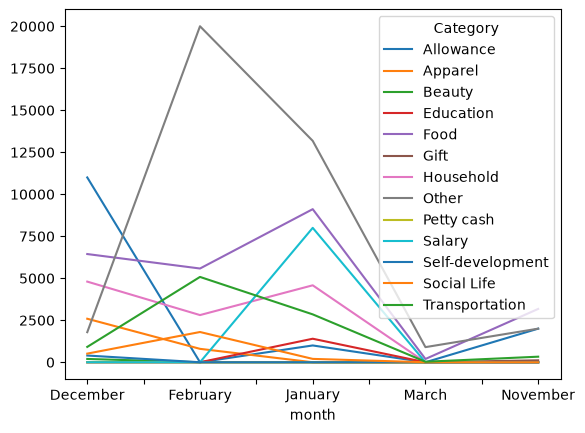

In [31]:
df.pivot_table(index = 'month', columns = 'Category',values = 'INR',aggfunc = 'sum',fill_value =0).plot()

<Axes: xlabel='month'>

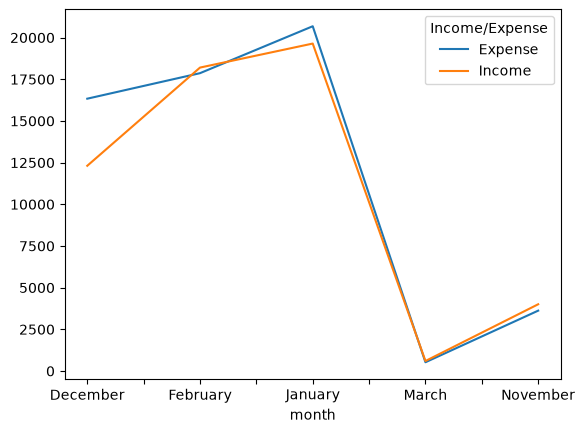

In [33]:
df.pivot_table(index = 'month', columns = 'Income/Expense' , values = 'INR', aggfunc = 'sum' , fill_value = 0).plot()

<Axes: xlabel='month'>

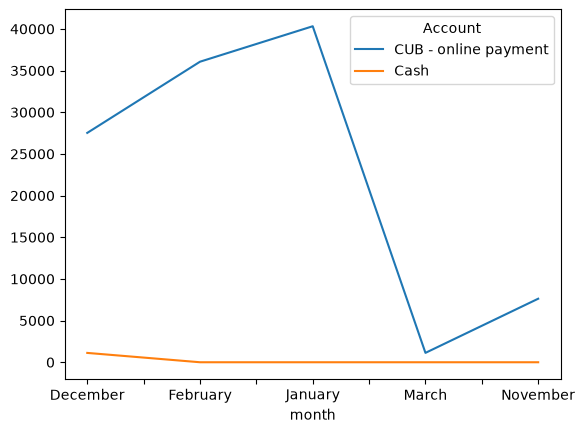

In [34]:
df.pivot_table(index = 'month', columns = 'Account', values = 'INR' , aggfunc = 'sum', fill_value = 0).plot()

# Vectorized String Operations

In [1]:
import numpy as np
import pandas as pd

In [3]:
# what are vectorized operations
a = np.array([1,2,3,4])
a*4

array([ 4,  8, 12, 16])

In [ ]:
# problem in vectorized operations in vanilla python
s = ['cat','mat',None,'rat']
[i.startswith('c')for i in s]

In [5]:
# How pandas solve this issue?
s = pd.Series(['cat','mat',None,'rat'])
# string acccessor
s.str.startswith('c')
# fast and optimized

0     True
1    False
2    False
3    False
dtype: bool

In [7]:
# import titanic
df = pd.read_csv('datasets-session-22/titanic.csv')
df['Name']

0                                Braund, Mr. Owen Harris
1      Cumings, Mrs. John Bradley (Florence Briggs Th...
2                                 Heikkinen, Miss. Laina
3           Futrelle, Mrs. Jacques Heath (Lily May Peel)
4                               Allen, Mr. William Henry
                             ...                        
886                                Montvila, Rev. Juozas
887                         Graham, Miss. Margaret Edith
888             Johnston, Miss. Catherine Helen "Carrie"
889                                Behr, Mr. Karl Howell
890                                  Dooley, Mr. Patrick
Name: Name, Length: 891, dtype: str

In [13]:
# Common Functions
# lower/upper/capitalize/title
df['Name'].str.upper()
df['Name'].str.capitalize()
df['Name'].str.title()
# len
df['Name'][df['Name'].str.len() == 82].values[0]
# strip
"          nitish       ".strip()
df['Name'].str.strip()

0                                Braund, Mr. Owen Harris
1      Cumings, Mrs. John Bradley (Florence Briggs Th...
2                                 Heikkinen, Miss. Laina
3           Futrelle, Mrs. Jacques Heath (Lily May Peel)
4                               Allen, Mr. William Henry
                             ...                        
886                                Montvila, Rev. Juozas
887                         Graham, Miss. Margaret Edith
888             Johnston, Miss. Catherine Helen "Carrie"
889                                Behr, Mr. Karl Howell
890                                  Dooley, Mr. Patrick
Name: Name, Length: 891, dtype: str

In [10]:
df['Name'].str.capitalize()

0                                Braund, mr. owen harris
1      Cumings, mrs. john bradley (florence briggs th...
2                                 Heikkinen, miss. laina
3           Futrelle, mrs. jacques heath (lily may peel)
4                               Allen, mr. william henry
                             ...                        
886                                Montvila, rev. juozas
887                         Graham, miss. margaret edith
888             Johnston, miss. catherine helen "carrie"
889                                Behr, mr. karl howell
890                                  Dooley, mr. patrick
Name: Name, Length: 891, dtype: str

In [12]:
# len
df['Name'][df['Name'].str.len() == 82].values[0]

'Penasco y Castellana, Mrs. Victor de Satode (Maria Josefa Perez de Soto y Vallejo)'

In [15]:
# split -> get
df['lastname'] = df['Name'].str.split(',').str.get(0)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,lastname
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Braund
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Cumings
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Heikkinen
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Futrelle
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Allen


In [18]:
df[['title','firstname']] = df['Name'].str.split(',').str.get(1).str.strip().str.split(' ', n=1, expand=True)
df.head()

df['title'].value_counts()

title
Mr.          517
Miss.        182
Mrs.         125
Master.       40
Dr.            7
Rev.           6
Major.         2
Mlle.          2
Col.           2
Don.           1
Mme.           1
Ms.            1
Lady.          1
Sir.           1
Capt.          1
the            1
Jonkheer.      1
Name: count, dtype: int64

In [19]:
# replace 
df['title'] = df['title'].str.replace('Ms.', 'Miss.')
df['title'] = df['title'].str.replace('Mlle.', 'Miss.')

In [21]:
df['title'].value_counts()

title
Mr.          517
Miss.        185
Mrs.         125
Master.       40
Dr.            7
Rev.           6
Major.         2
Col.           2
Don.           1
Mme.           1
Lady.          1
Sir.           1
Capt.          1
the            1
Jonkheer.      1
Name: count, dtype: int64

In [22]:
# filtering 
# startswith/endswith
df[df['firstname'].str.endswith('A')]
# isdigit/isalpha
df[df['firstname'].str.isdigit()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,lastname,title,firstname


In [ ]:
# applying regex
# contains
# search john - both case
df[df['firstname'].str.contains('john', case = False)]
# find last name with start and end char vowel
df[df['lastname'].str.contains('^[^aeiouAEIOU].+[^aeiouAEIOU]$')]

In [24]:
# slicing 
df['Name'].str[::-1]

0                                sirraH newO .rM ,dnuarB
1      )reyahT sggirB ecnerolF( yeldarB nhoJ .srM ,sg...
2                                 aniaL .ssiM ,nenikkieH
3           )leeP yaM yliL( htaeH seuqcaJ .srM ,ellertuF
4                               yrneH mailliW .rM ,nellA
                             ...                        
886                                sazouJ .veR ,alivtnoM
887                         htidE teragraM .ssiM ,maharG
888             "eirraC" neleH enirehtaC .ssiM ,notsnhoJ
889                                llewoH lraK .rM ,rheB
890                                  kcirtaP .rM ,yelooD
Name: Name, Length: 891, dtype: str

# Timestamp Object

- Time stamps reference particular moments in time (e.g., Oct 24th , 2022 at 7:00pm)

In [26]:
import numpy as np 
import pandas as pd

# Creating Timestamp Object

In [27]:
# Creating a timestamp
type(pd.Timestamp('2023/1/5'))

pandas.Timestamp

In [28]:
# variations
pd.Timestamp('2023-1-5')
pd.Timestamp('2023, 1, 5')

Timestamp('2023-01-05 00:00:00')

In [29]:
# only Year
pd.Timestamp('2023')

Timestamp('2023-01-01 00:00:00')

In [30]:
# using text
pd.Timestamp('5th January 2023')

Timestamp('2023-01-05 00:00:00')

In [31]:
# providing time also
pd.Timestamp('5th January 2023 9:21AM')
# pd.Timestamp('2023/1/5/9/21')

Timestamp('2023-01-05 09:21:00')

In [ ]:
# AM PM

In [32]:
# using datetime.datetime object
import datetime as dt
x = pd.Timestamp(dt.datetime(2023,1,5,9,21,56))
x

Timestamp('2023-01-05 09:21:56')

In [33]:
# fetching Attributes
x.year
x.month
x.day
x.hour
x.minute
x.second

56

In [ ]:
# why seperate objects to handle data and time when python already has datetime functionality?

- Syntax wise datetime is very convenient
- But the performance takes a hit while working with huge data. List vs Numpy Array
- The weakness of python's datetime format inspired the Numpy team to add a set of native time series data type to Numpy.
- The datetime64 dtype encodes dates as 64-bit integers, and thus allows arrays of dates to be represented very compactly.

In [34]:
import numpy as np
date = np.array('2015-07-04', dtype=np.datetime64)
date

array('2015-07-04', dtype='datetime64[D]')

In [36]:
date + np.arange(12)

array(['2015-07-04', '2015-07-05', '2015-07-06', '2015-07-07',
       '2015-07-08', '2015-07-09', '2015-07-10', '2015-07-11',
       '2015-07-12', '2015-07-13', '2015-07-14', '2015-07-15'],
      dtype='datetime64[D]')

- Because of the uniform type in Numpy datetime64 arrays, this type of operation can be accomplished more quickly than if we
  were working directly with Python's datetime objects, especially as arrays get large.
- Pandas Timestamp object combines the ease-of-use of python datetime with the efficient storage and vectorized interface of numpy.datetime64.
- From a group of these Timestamp objects, Pandas can construct a DatetimeIndex that can be used to index data in Series or dataframe.

# DatetimeIndex Object

- A collection of Pandas timestamp.

In [38]:
# from strings
type(pd.DatetimeIndex(['2023/1/1','2022/1/1','2021/1/1']))

pandas.DatetimeIndex

In [41]:
# using datetime object
pd.DatetimeIndex([dt.datetime(2023,1,1),dt.datetime(2022,1,1),dt.datetime(2021,1,1)])

DatetimeIndex(['2023-01-01', '2022-01-01', '2021-01-01'], dtype='datetime64[us]', freq=None)

In [42]:
# using pd.timestamp
dt_index = pd.DatetimeIndex([pd.Timestamp(2023,1,1),pd.Timestamp(2022,1,1),pd.Timestamp(2021,1,1)])

In [47]:
# using datetimeindex as series index
pd.Series([1,2,3], index = dt_index)

2023-01-01    1
2022-01-01    2
2021-01-01    3
dtype: int64

# date_range function

In [45]:
# generates daily dates in a given range 
pd.date_range(start= '2023/1/5',end = '2023/1/28', freq= '3D')

DatetimeIndex(['2023-01-05', '2023-01-08', '2023-01-11', '2023-01-14',
               '2023-01-17', '2023-01-20', '2023-01-23', '2023-01-26'],
              dtype='datetime64[us]', freq='3D')

In [46]:
# alternate dates in a given range 
pd.date_range(start='2023/1/5',end='2023/2/28',freq='3D')

DatetimeIndex(['2023-01-05', '2023-01-08', '2023-01-11', '2023-01-14',
               '2023-01-17', '2023-01-20', '2023-01-23', '2023-01-26',
               '2023-01-29', '2023-02-01', '2023-02-04', '2023-02-07',
               '2023-02-10', '2023-02-13', '2023-02-16', '2023-02-19',
               '2023-02-22', '2023-02-25', '2023-02-28'],
              dtype='datetime64[us]', freq='3D')

In [48]:
# B -> business days
pd.date_range(start='2023/1/5',end='2023/2/28',freq='B')

DatetimeIndex(['2023-01-05', '2023-01-06', '2023-01-09', '2023-01-10',
               '2023-01-11', '2023-01-12', '2023-01-13', '2023-01-16',
               '2023-01-17', '2023-01-18', '2023-01-19', '2023-01-20',
               '2023-01-23', '2023-01-24', '2023-01-25', '2023-01-26',
               '2023-01-27', '2023-01-30', '2023-01-31', '2023-02-01',
               '2023-02-02', '2023-02-03', '2023-02-06', '2023-02-07',
               '2023-02-08', '2023-02-09', '2023-02-10', '2023-02-13',
               '2023-02-14', '2023-02-15', '2023-02-16', '2023-02-17',
               '2023-02-20', '2023-02-21', '2023-02-22', '2023-02-23',
               '2023-02-24', '2023-02-27', '2023-02-28'],
              dtype='datetime64[us]', freq='B')

In [50]:
# w -> one week per day
pd.date_range(start='2023/1/5',end='2023/2/28',freq='W-THU')

DatetimeIndex(['2023-01-05', '2023-01-12', '2023-01-19', '2023-01-26',
               '2023-02-02', '2023-02-09', '2023-02-16', '2023-02-23'],
              dtype='datetime64[us]', freq='W-THU')

In [54]:
# H -> Hourly data (factor)
pd.date_range(start='2023/1/5',end='2023/2/28',freq='6h')

DatetimeIndex(['2023-01-05 00:00:00', '2023-01-05 06:00:00',
               '2023-01-05 12:00:00', '2023-01-05 18:00:00',
               '2023-01-06 00:00:00', '2023-01-06 06:00:00',
               '2023-01-06 12:00:00', '2023-01-06 18:00:00',
               '2023-01-07 00:00:00', '2023-01-07 06:00:00',
               ...
               '2023-02-25 18:00:00', '2023-02-26 00:00:00',
               '2023-02-26 06:00:00', '2023-02-26 12:00:00',
               '2023-02-26 18:00:00', '2023-02-27 00:00:00',
               '2023-02-27 06:00:00', '2023-02-27 12:00:00',
               '2023-02-27 18:00:00', '2023-02-28 00:00:00'],
              dtype='datetime64[us]', length=217, freq='6h')

In [58]:
# M -> Month end
pd.date_range(start='2023/1/5',end='2023/2/28',freq='ME')

DatetimeIndex(['2023-01-31', '2023-02-28'], dtype='datetime64[us]', freq='ME')

In [59]:
# MS -> Month start
pd.date_range(start='2023/1/5',end='2023/2/28',freq='MS')

DatetimeIndex(['2023-02-01'], dtype='datetime64[us]', freq='MS')

In [61]:
# A -> year end
pd.date_range(start='2023/1/5',end='2023/2/28',freq='ME')

DatetimeIndex(['2023-01-31', '2023-02-28'], dtype='datetime64[us]', freq='ME')

In [62]:
# using periods (number of results )
pd.date_range(start='2023/1/5',end='2023/2/28',freq='ME')


DatetimeIndex(['2023-01-31', '2023-02-28'], dtype='datetime64[us]', freq='ME')

# to_datetime Function

- coverts an existing objects to pandas timestamp/datetimeindex object.

In [63]:
# simple series example
s = pd.Series(['2023/1/1','2022/1/1','2021/1/1'])
pd.to_datetime(s).dt.day_name()

0      Sunday
1    Saturday
2      Friday
dtype: str

In [64]:
# with errors
s = pd.Series(['2023/1/1','2022/1/1','2021/130/1'])
pd.to_datetime(s, errors = 'coerce').dt.month_name()

0    January
1    January
2        NaN
dtype: str

In [65]:
df = pd.read_csv('datasets-session-22/expense_data.csv')

In [67]:
df.shape

(277, 11)

In [68]:
df.head()

,Date,Account,Category,Subcategory,Note,INR,Income/Expense,Note.1,Amount,Currency,Account.1
0,3/2/2022 10:11,CUB - online payment,Food,NaN,Brownie,50.0,Expense,NaN,50.0,INR,50.0
1,3/2/2022 10:11,CUB - online payment,Other,NaN,To lended people,300.0,Expense,NaN,300.0,INR,300.0
2,3/1/2022 19:50,CUB - online payment,Food,NaN,Dinner,78.0,Expense,NaN,78.0,INR,78.0
3,3/1/2022 18:56,CUB - online payment,Transportation,NaN,Metro,30.0,Expense,NaN,30.0,INR,30.0
4,3/1/2022 18:22,CUB - online payment,Food,NaN,Snacks,67.0,Expense,NaN,67.0,INR,67.0


In [70]:
df['Date'] = pd.to_datetime(df['Date'])

In [71]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 277 entries, 0 to 276
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Date            277 non-null    datetime64[us]
 1   Account         277 non-null    str           
 2   Category        277 non-null    str           
 3   Subcategory     0 non-null      float64       
 4   Note            273 non-null    str           
 5   INR             277 non-null    float64       
 6   Income/Expense  277 non-null    str           
 7   Note.1          0 non-null      float64       
 8   Amount          277 non-null    float64       
 9   Currency        277 non-null    str           
 10  Account.1       277 non-null    float64       
dtypes: datetime64[us](1), float64(5), str(5)
memory usage: 23.9 KB


 # dt accessor

-  Accessor object for datetimelike properties of the Series value.

In [72]:
df['Date'].dt.is_quarter_start

0      False
1      False
2      False
3      False
4      False
       ...  
272    False
273    False
274    False
275    False
276    False
Name: Date, Length: 277, dtype: bool

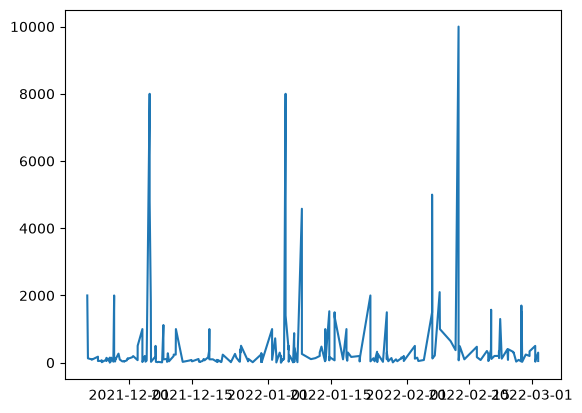

In [73]:
# plot graph
import matplotlib.pyplot as plt
plt.plot(df['Date'],df['INR'])

In [74]:
# day name wise bar chart/month wise bar chart
df['day_name'] = df['Date'].dt.day_name()

In [75]:
df.head()

,Date,Account,Category,Subcategory,Note,INR,Income/Expense,Note.1,Amount,Currency,Account.1,day_name
0,2022-03-02 10:11:00,CUB - online payment,Food,NaN,Brownie,50.0,Expense,NaN,50.0,INR,50.0,Wednesday
1,2022-03-02 10:11:00,CUB - online payment,Other,NaN,To lended people,300.0,Expense,NaN,300.0,INR,300.0,Wednesday
2,2022-03-01 19:50:00,CUB - online payment,Food,NaN,Dinner,78.0,Expense,NaN,78.0,INR,78.0,Tuesday
3,2022-03-01 18:56:00,CUB - online payment,Transportation,NaN,Metro,30.0,Expense,NaN,30.0,INR,30.0,Tuesday
4,2022-03-01 18:22:00,CUB - online payment,Food,NaN,Snacks,67.0,Expense,NaN,67.0,INR,67.0,Tuesday


<Axes: xlabel='day_name'>

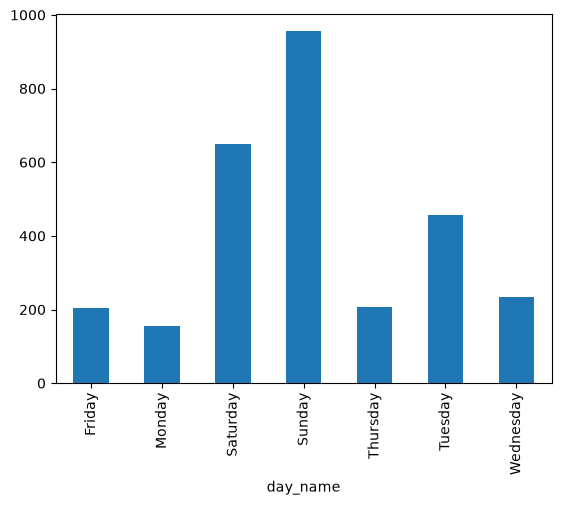

In [78]:
df.groupby('day_name')['INR'].mean().plot(kind='bar')

In [79]:
df['month_name'] = df['Date'].dt.month_name()

In [80]:
df.head()

,Date,Account,Category,Subcategory,Note,INR,Income/Expense,Note.1,Amount,Currency,Account.1,day_name,month_name
0,2022-03-02 10:11:00,CUB - online payment,Food,NaN,Brownie,50.0,Expense,NaN,50.0,INR,50.0,Wednesday,March
1,2022-03-02 10:11:00,CUB - online payment,Other,NaN,To lended people,300.0,Expense,NaN,300.0,INR,300.0,Wednesday,March
2,2022-03-01 19:50:00,CUB - online payment,Food,NaN,Dinner,78.0,Expense,NaN,78.0,INR,78.0,Tuesday,March
3,2022-03-01 18:56:00,CUB - online payment,Transportation,NaN,Metro,30.0,Expense,NaN,30.0,INR,30.0,Tuesday,March
4,2022-03-01 18:22:00,CUB - online payment,Food,NaN,Snacks,67.0,Expense,NaN,67.0,INR,67.0,Tuesday,March


<Axes: xlabel='month_name'>

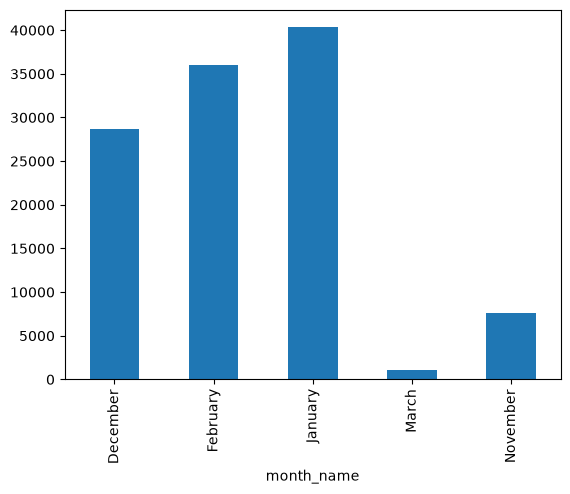

In [81]:
df.groupby('month_name')['INR'].sum().plot(kind='bar')

In [82]:
df[df['Date'].dt.is_month_end]

,Date,Account,Category,Subcategory,Note,INR,Income/Expense,Note.1,Amount,Currency,Account.1,day_name,month_name
7,2022-02-28 11:56:00,CUB - online payment,Food,NaN,Pizza,339.15,Expense,NaN,339.15,INR,339.15,Monday,February
8,2022-02-28 11:45:00,CUB - online payment,Other,NaN,From kumara,200.00,Income,NaN,200.00,INR,200.00,Monday,February
61,2022-01-31 08:44:00,CUB - online payment,Transportation,NaN,Vnr to apk,50.00,Expense,NaN,50.00,INR,50.00,Monday,January
62,2022-01-31 08:27:00,CUB - online payment,Other,NaN,To vicky,200.00,Expense,NaN,200.00,INR,200.00,Monday,January
63,2022-01-31 08:26:00,CUB - online payment,Transportation,NaN,To ksr station,153.00,Expense,NaN,153.00,INR,153.00,Monday,January
242,2021-11-30 14:24:00,CUB - online payment,Gift,NaN,Bharath birthday,115.00,Expense,NaN,115.00,INR,115.00,Tuesday,November
243,2021-11-30 14:17:00,CUB - online payment,Food,NaN,Lunch with company,128.00,Expense,NaN,128.00,INR,128.00,Tuesday,November
244,2021-11-30 10:11:00,CUB - online payment,Food,NaN,Breakfast,70.00,Expense,NaN,70.00,INR,70.00,Tuesday,November
